# ARIA - LITE

ARIA Lite is a lightweight GraphRAG-based biomedical research assistant focused on breast cancer AI literature.

The project combines two retrieval paradigms:

1. Semantic Retrieval
   Dense vector embeddings are used to retrieve papers semantically related to a user query.

2. Graph-Based Retrieval
   Biomedical entities such as genes and drugs are extracted from papers and represented as relationships in a lightweight knowledge graph.

By combining these two approaches, the system aims to provide more grounded and explainable retrieval compared to traditional vector-only RAG systems.

The project is intentionally scoped for rapid iteration and learning:
- ~300-500 PubMed papers
- Abstract-only corpus
- Lightweight graph construction
- Citation-grounded responses

Core technologies:
- PubMed / Entrez API
- SciSpacy
- Sentence Transformers
- FAISS
- Python + Google Colab

End Goal:
Build a small but functional biomedical GraphRAG system capable of retrieving relevant breast cancer AI papers and generating grounded answers with PMID citations.

# 5_graph_clustering.ipynb

PURPOSE:
Perform community detection on the biomedical entity graph to discover higher-level research themes.

This step extends the ARIA-Lite GraphRAG system by adding a global “concept grouping” layer over the entity network.

The clustering process supports:

1. Entity community detection (global concept discovery)
   - Applies Louvain/Leiden clustering on the entity subgraph
   - Uses weighted biomedical relations (hard-rule + CO_OCCURS fallback)
   - Groups entities into semantically coherent research communities

2. Weighted relation-aware clustering
   - Hard-rule edges (PREDICTS, APPLIED_TO, STUDIED_WITH, etc.) carry strong weight
   - CO_OCCURS edges are downweighted as weak contextual signals
   - Ensures communities reflect meaningful biomedical structure, not just co-occurrence

3. Community assignment back to graph
   - Each entity node is assigned a `community_id`
   - Communities are stored as node-level metadata in the original GraphRAG graph
   - Preserves full graph while enriching it with global structure

4. Visualization of learned communities
   - Sample subgraph visualization of entity clusters
   - Provides qualitative validation of community structure
   - Helps interpret biomedical concept groupings

This is the global abstraction layer of ARIA-Lite GraphRAG.
It transforms the entity graph into a community-structured biomedical knowledge space for future global retrieval and summarization.

In [1]:
# ============================================================
# SECTION 1 — Install Dependencies
# ============================================================

!pip install networkx python-louvain matplotlib leidenalg igraph
!pip install transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


In [7]:
# ============================================================
# SECTION 2 — Imports
# ============================================================

from google.colab import drive
import os
import pickle
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from transformers import pipeline
import torch

In [3]:
# ============================================================
# SECTION 3 — Load Graph
# ============================================================

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2"

GRAPH_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "aria_lite_graph_v2_1.pkl")

with open(GRAPH_FILE_PATH, "rb") as f:
    G = pickle.load(f)

print("Graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Mounted at /content/drive
Graph loaded
Nodes: 2105
Edges: 22506


In [4]:
# ============================================================
# SECTION 4 — Extract Entity Subgraph (IMPORTANT)
# ============================================================

entity_nodes = [
    n for n, d in G.nodes(data=True)
    if d.get("type") == "entity"
]

H = G.subgraph(entity_nodes).copy()

print("Entity subgraph:")
print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())

Entity subgraph:
Nodes: 970
Edges: 14695


In [5]:
# ============================================================
# SECTION 5 — Build Weighted Edge Graph for Clustering
# ============================================================

EDGE_TYPES_KEEP = {
    "STUDIED_WITH",
    "COMPARED_WITH",
    "USES",
    "APPLIED_TO",
    "PREDICTS",
    "IMPACTS",
    "INVOLVES",
    "AFFECTS",
    "ASSOCIATED_WITH",
    "BIOMARKER_FOR",
    "CO_OCCURS"
}

H_cluster = nx.Graph()

for u, v, d in H.edges(data=True):

    if d.get("type") not in EDGE_TYPES_KEEP:
        continue

    weight = d.get("weight", 1.0)

    # downweight CO_OCCURS
    if d.get("type") == "CO_OCCURS":
        weight *= 0.3

    if H_cluster.has_edge(u, v):
        H_cluster[u][v]["weight"] += weight
    else:
        H_cluster.add_edge(u, v, weight=weight)

print("Cluster graph built")
print("Nodes:", H_cluster.number_of_nodes())
print("Edges:", H_cluster.number_of_edges())

Cluster graph built
Nodes: 968
Edges: 14695


In [8]:
# ============================================================
# SECTION 6 — Louvain Clustering
# ============================================================

partition = community_louvain.best_partition(
    H_cluster,
    weight="weight",
    resolution=1.2
)

print("Communities found:", len(set(partition.values())))

Communities found: 11


In [9]:
# ============================================================
# SECTION 7 — Attach Community IDs Back to Graph
# ============================================================

for node, comm_id in partition.items():

    if G.has_node(node):
        G.nodes[node]["community_id"] = comm_id

print("Community IDs assigned back to original graph")

Community IDs assigned back to original graph


In [10]:
# ============================================================
# SECTION 8 — Save Updated Graph (NEW FILE)
# ============================================================

NEW_GRAPH_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "aria_lite_graph_v2_1_clustered.pkl"
)

with open(NEW_GRAPH_PATH, "wb") as f:
    pickle.dump(G, f)

print("Saved clustered graph at:", NEW_GRAPH_PATH)

Saved clustered graph at: /content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2/data/processed/aria_lite_graph_v2_1_clustered.pkl


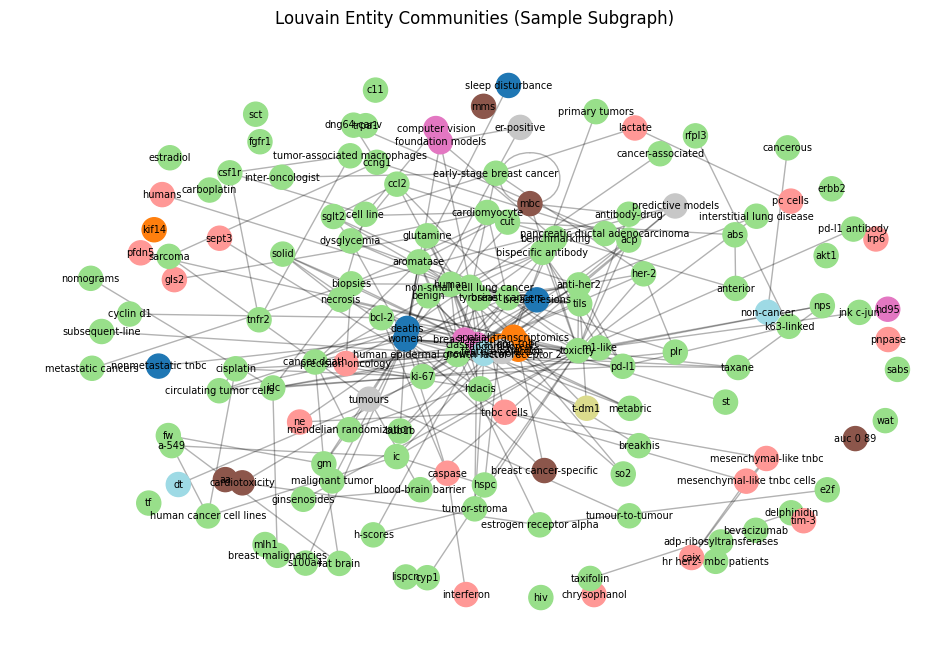

In [11]:
# ============================================================
# SECTION 9 — Visualization (Louvain Communities)
# ============================================================

import random

sample_nodes = random.sample(list(H_cluster.nodes()), min(150, H_cluster.number_of_nodes()))
subG = H_cluster.subgraph(sample_nodes)

colors = []
communities = [partition[n] for n in subG.nodes()]

unique_comms = list(set(communities))
color_map = {c: i for i, c in enumerate(unique_comms)}

for n in subG.nodes():
    colors.append(color_map[partition[n]])

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=300
)

nx.draw_networkx_edges(subG, pos, alpha=0.3)

nx.draw_networkx_labels(subG, pos, font_size=7)

plt.title("Louvain Entity Communities (Sample Subgraph)")
plt.axis("off")
plt.show()

In [12]:
# ============================================================
# SECTION 10 — Sanity check of communities
# ============================================================

from collections import defaultdict

community_groups = defaultdict(list)

for entity, cid in partition.items():
    community_groups[cid].append(entity)

# sort communities by size (optional but very helpful)
sorted_groups = sorted(community_groups.items(), key=lambda x: len(x[1]), reverse=True)

for cid, entities in sorted_groups:
    print(f"\n====================")
    print(f"Community {cid} | Size: {len(entities)}")
    print(f"====================")
    print(", ".join(entities[:30]))  # show top 30 for readability

    if len(entities) > 30:
        print(f"... +{len(entities) - 30} more")


Community 2 | Size: 572
toxicity, estrogen receptor, antitumor, anticancer, breast cancer, breast cancer cells, mcf-7 breast cancer cells, bax, mcf-7 cells, beclin-1, bcl-xl, breast cancer cell, bcl-2, cq, lc3b-ii, caspase-3 7, lc3-ii, persisters, estrogen receptor alpha, disease, cdk4 6, e2f, tmsb10, patient, endothelial cells, c1, llama, asps, breast, ccl2
... +542 more

Community 4 | Size: 155
death, cell, tumor, caspase, cancer, cancer cell, single-cell, tumor cell, mitochondrial dysfunction, sp, cellular, aln, pc12 cells, triple-negative breast cancer, san, tnbc, tnbc cell, tumor cells, ne, tnbc cells, th, antitumour, icis, ici, luminal b, luminal a, immune cell, hypoxia, tnbc patients, organoid
... +125 more

Community 0 | Size: 67
mcf-7 cell line, arrest, estrogen, molecular docking, women, tamoxifen, nci, ai, artificial intelligence, anxiety, diagnostic accuracy, deaths, malignancy, oncotype dx, dbt, explainable artificial intelligence, tuberculosis, xai, multiple cancer, fati

In [13]:
# ============================================================
# SECTION 11 — Build Community → Entity Mapping
# ============================================================

from collections import defaultdict

community_to_entities = defaultdict(list)

for node, data in G.nodes(data=True):

    if data.get("type") != "entity":
        continue

    comm_id = data.get("community_id", None)

    if comm_id is not None:
        community_to_entities[comm_id].append(node)

print("Community mappings built")
print("Total communities:", len(community_to_entities))

Community mappings built
Total communities: 11


In [14]:
# ============================================================
# SECTION 12 — Collect Supporting Sections per Community
# ============================================================

community_to_sections = defaultdict(set)

for comm_id, entities in community_to_entities.items():

    for ent in entities:

        # neighbors of entity
        for nbr in G.neighbors(ent):

            nbr_data = G.nodes[nbr]

            # only section nodes
            if nbr_data.get("type") == "section":

                community_to_sections[comm_id].add(nbr)

print("Community supporting sections collected")

Community supporting sections collected


In [15]:
# ============================================================
# SECTION 13 — Create Lightweight Community Summaries
# ============================================================

MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

llm = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

print("LLM loaded")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

LLM loaded


In [16]:
# ============================================================
# SECTION 14 — LLM Community Summarization
# ============================================================

community_summaries = {}

for comm_id in community_to_entities.keys():

    print(f"\nProcessing community {comm_id}...")

    entities = community_to_entities[comm_id]
    sections = list(community_to_sections[comm_id])

    # --------------------------------------------------------
    # Representative entities
    # --------------------------------------------------------

    top_entities = entities[:25]

    # --------------------------------------------------------
    # Representative section snippets
    # --------------------------------------------------------

    snippets = []

    for sid in sections[:5]:

        text = G.nodes[sid].get("text", "")

        if len(text) > 0:
            snippets.append(text[:600])

    joined_snippets = "\n\n".join(snippets)

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    prompt = f"""
              You are analyzing a biomedical research graph community.

              Top biomedical entities:
              {', '.join(top_entities)}

              Representative biomedical text snippets:
              {joined_snippets}

              Task:
              Write a concise scientific summary (4-6 sentences) describing:
              1. The main biomedical research theme
              2. Important ML/clinical/genomic concepts
              3. Relationships between concepts
              4. Likely application area

              Keep the summary factual and concise.
              """
    # --------------------------------------------------------
    # Generate summary
    # --------------------------------------------------------

    output = llm(
        prompt,
        max_new_tokens=180,
        do_sample=False,
        truncation=True
    )

    generated = output[0]["generated_text"]

    summary_text = generated[len(prompt):].strip()

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    community_summaries[comm_id] = {
        "community_id": comm_id,
        "num_entities": len(entities),
        "num_sections": len(sections),
        "top_entities": top_entities,
        "summary": summary_text
    }

print("LLM community summaries completed")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.



Processing community 1...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Processing community 4...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Processing community 8...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Processing community 3...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Processing community 9...
LLM community summaries completed


In [17]:
# ============================================================
# SECTION 15 — Attach Summaries to Graph
# ============================================================

G.graph["community_summaries"] = community_summaries

print("Community summaries attached to graph")

Community summaries attached to graph


In [18]:
# ============================================================
# SECTION 16 — Inspect Summaries
# ============================================================

for comm_id, summary in community_summaries.items():

    print("\n================================================")
    print(f"COMMUNITY {comm_id}")
    print("================================================")

    print("\nTop entities:")
    print(", ".join(summary["top_entities"][:15]))

    print("\nLLM SUMMARY:\n")
    print(summary["summary"])


COMMUNITY 1

Top entities:
machine learning, random forest, luminal breast cancer, recursive feature elimination, omics, multi-omics, non-tnbc, tcga, spatial transcriptomics, cibersort, rna-seq, transcriptomics, single-cell rna-seq, estimate, st3gal4

LLM SUMMARY:

Scientific Summary:
              
              The main biomedical research theme revolves around the integration of machine learning (ML) and deep learning (DL) techniques with imaging-based spatial transcriptomics (ST) to enhance the detection and analysis of breast cancer. This approach addresses the limitation of gene panel size in ST by employing a novel deep learning framework, STGNET, which utilizes generative adversarial networks (GANs) and graph neural networks to extend gene panel coverage. The study also explores the genomic profiles of PIK3CA-altered and PIK3CA-wild type tumors, revealing distinct patterns and the potential for targeted therapies, such as alpelisib, in patients with specific mutational burdens

In [19]:
# ============================================================
# SECTION 17 — Save Updated Graph
# ============================================================

NEW_GRAPH_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "aria_lite_graph_v2_1_communities.pkl"
)

with open(NEW_GRAPH_PATH, "wb") as f:
    pickle.dump(G, f)

print("Graph with community summaries saved")
print("Saved at:", NEW_GRAPH_PATH)

Graph with community summaries saved
Saved at: /content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2/data/processed/aria_lite_graph_v2_1_communities.pkl
